In [6]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report as CR, confusion_matrix as cm, ConfusionMatrixDisplay

# Active Coding with Classification Algorithms

In [2]:
data = pd.read_csv('https://github.com/dvasiliu/AML/blob/main/Data%20Sets/ElectricalGridData.csv?raw=true')

In [3]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable


In [15]:
# extract the features and the labels for the "train" data
x = data.loc[:,'tau1':'g4'].values
y = data['stabf'].values

In [10]:
labels = LabelEncoder()

In [11]:
yb = labels.fit_transform(y)

In [13]:
yb.dtype

dtype('int64')

In [17]:
yb[0]

np.int64(1)

In [4]:
y[y=='unstable']=1

In [5]:
y[y=='stable']=0

In [18]:
# here C is 1/alpha where alpha is the regularization hyperparameter for Ridge
model = LogisticRegression(C=100,max_iter=1000)

In [19]:
model.fit(x,yb)

LogisticRegression(C=100, max_iter=1000)

In [21]:
# to check the overall accuracy
model.score(x,yb)

0.8166

Critical Thinking: How do you interpret this score?

In [22]:
print(CR(yb,model.predict(x)))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74      3620
           1       0.84      0.88      0.86      6380

    accuracy                           0.82     10000
   macro avg       0.80      0.79      0.80     10000
weighted avg       0.81      0.82      0.81     10000



In [34]:
pd.DataFrame(data=cm(y,model.predict(x)), columns=["0","1"], index=["0","1"])

,0,1
0,2557,1063
1,771,5609


In [35]:
# task: connect the meaning of precision and recall with the elements from a Confusion Matrix

## How is SVM performing for the same data?

In [25]:
# how about using SVMs? Do we get any better "mileage?"
model = SVC(kernel='poly', degree=2,C=2)
model.fit(x,yb)

SVC(C=2, degree=2, kernel='poly')

In [26]:
print(CR(yb,model.predict(x)))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      3620
           1       0.92      0.93      0.93      6380

    accuracy                           0.91     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.91      0.91      0.91     10000



In [28]:
model = SVC(kernel='linear',C=200)
model.fit(x,yb)
print(CR(yb,model.predict(x)))

              precision    recall  f1-score   support

           0       0.77      0.70      0.73      3620
           1       0.84      0.88      0.86      6380

    accuracy                           0.82     10000
   macro avg       0.80      0.79      0.80     10000
weighted avg       0.81      0.82      0.81     10000



In [31]:
# how about using an RBF kernel for SVM?
model = SVC(kernel='rbf',C=2, gamma=0.1)
model.fit(x,yb)
print(CR(yb,model.predict(x)))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      3620
           1       0.97      0.98      0.98      6380

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## We infer that high $\gamma$ is overfitting to the Train Data

In [51]:
# so we need cross validations
k = 5
reports = []
for ind in np.array_split(np.random.permutation(range(len(x))),k):
    xtest = x[ind]
    ytest = yb[ind]
    xtrain = x[np.delete(range(len(x)),ind)]
    ytrain = yb[np.delete(range(len(x)),ind)]
    model = SVC(kernel='rbf',C=2, gamma=0.1)
    model.fit(xtrain,ytrain)
    print(model.score(xtest,ytest))
    reports.append(CR(ytest,model.predict(xtest),output_dict=True))

0.92
0.928
0.9255
0.932
0.9145


In [45]:
recall0 = reports[0]['0']['recall']
recall1 = reports[1]['1']['recall']

In [44]:
recall0

0.8732590529247911

In [46]:
recall1

0.9628751974723538

## Let's present the ROC curves plotting the TPR vs FPR for each fold

In [69]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

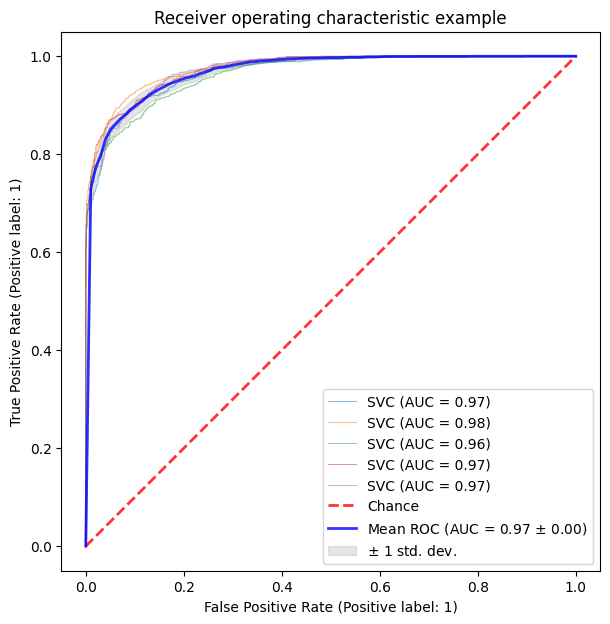

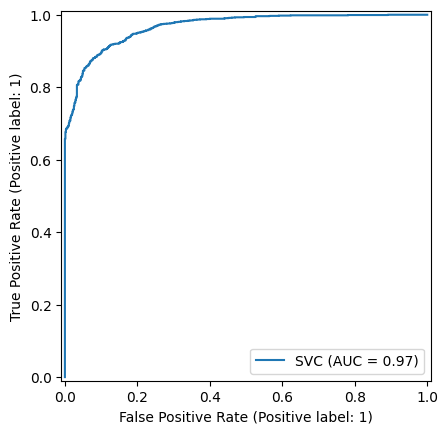

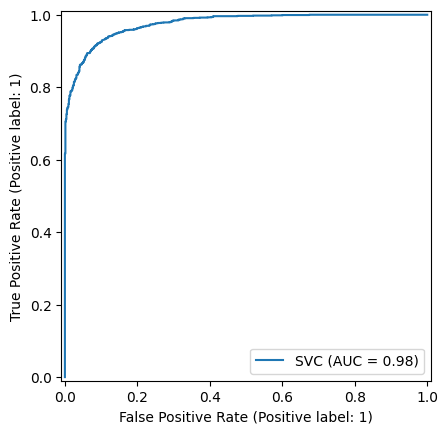

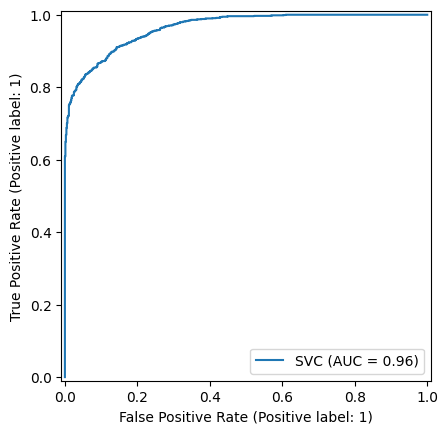

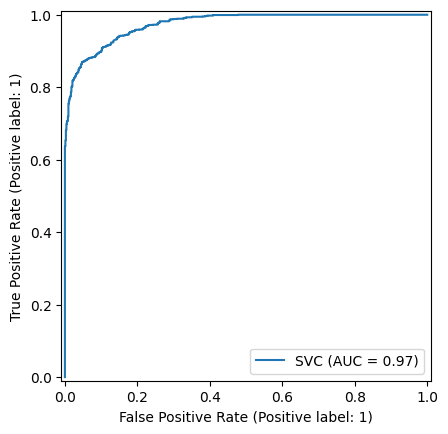

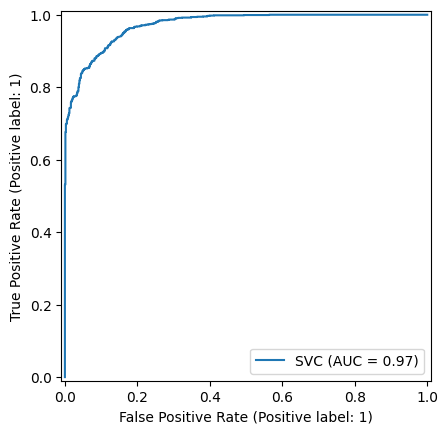

In [70]:
# we will use the class method ROCDisplay
n_samples, n_features = x.shape


# #############################################################################
# Classification and ROC analysis

# Run classifier with cross-validation and plot ROC curves
cv = StratifiedKFold(n_splits=5,shuffle = True,random_state=301)
classifier = SVC(kernel='rbf', gamma=0.1,probability=True)
#classifier = LogisticRegression(solver='lbfgs',max_iter=100000)


# define tracker variables
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig,ax = plt.subplots(figsize=(7,7))
for i, (train, test) in enumerate(cv.split(x, yb)):
    classifier.fit(x[train], yb[train])
    viz = RocCurveDisplay.from_estimator(classifier, x[test], yb[test])
    viz.plot(ax=ax,alpha=0.5,lw=0.75)
    fpr, tpr, thresholds = roc_curve(yb[test], classifier.predict_proba(x[test])[:,1])
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Receiver operating characteristic example")
ax.legend(loc="lower right")
plt.show()

In [56]:
classifier.fit(xtrain,ytrain)

SVC(gamma=0.1, probability=True)

In [58]:
classifier.predict_proba([xtest[9]])

array([[0.70700712, 0.29299288]])

In [60]:
classifier.predict([xtest[9]])

array([0])

In [61]:
ytest[9]

np.int64(0)

In [64]:
classifier.predict_proba(xtest)[:,1]

array([0.9960425 , 0.15289451, 0.97236387, ..., 0.94866809, 0.06106772,
       0.05095477], shape=(2000,))

In [66]:
yb[test]

array([0, 0, 1, ..., 1, 0, 1], shape=(2000,))

In [68]:
roc_curve(yb[test], classifier.predict_proba(x[test])[:,1])

(array([0.        , 0.        , 0.        , 0.00138122, 0.00138122,
        0.00276243, 0.00276243, 0.00414365, 0.00414365, 0.00552486,
        0.00552486, 0.00690608, 0.00690608, 0.00828729, 0.00828729,
        0.00966851, 0.00966851, 0.01104972, 0.01104972, 0.01243094,
        0.01243094, 0.01381215, 0.01381215, 0.01519337, 0.01519337,
        0.01657459, 0.01657459, 0.0179558 , 0.0179558 , 0.01933702,
        0.01933702, 0.02071823, 0.02071823, 0.02209945, 0.02209945,
        0.02348066, 0.02348066, 0.02486188, 0.02486188, 0.03038674,
        0.03038674, 0.03176796, 0.03176796, 0.03314917, 0.03314917,
        0.03453039, 0.03453039, 0.0359116 , 0.0359116 , 0.03729282,
        0.03729282, 0.03867403, 0.03867403, 0.04005525, 0.04005525,
        0.04143646, 0.04143646, 0.0441989 , 0.0441989 , 0.04558011,
        0.04558011, 0.04696133, 0.04696133, 0.04834254, 0.04834254,
        0.04972376, 0.04972376, 0.05110497, 0.05110497, 0.05248619,
        0.05248619, 0.0538674 , 0.0538674 , 0.05

## Examples with a Multiclass Classification

In [71]:
data = pd.read_csv('https://github.com/dvasiliu/AML/blob/main/Data%20Sets/mobile.csv?raw=true')

In [72]:
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [73]:
data['price_range'].unique()

array([1, 2, 3, 0])

In [74]:
# you need to think how to scale the data correctly
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [76]:
x = data.loc[:,'battery_power':'wifi'].values